# First plotting attempt of example data

In [1]:
#import packages
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import inspect

#### define output folder

In [40]:
#outputs

#get path
current_folder_path = os.getcwd()
parent_folder_path = os.path.abspath(os.path.join(current_folder_path, os.pardir))

# Specify the subfolder name
output_folder = '/02_plots/'

#create path to correct folder
images_folder_path = parent_folder_path + output_folder

#replace \ by correct one:/
images_folder_path = images_folder_path.replace("\\", "/")

In [11]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes with coordinates (to have a better illustration)
nodes = {
    'S1': (0, 1),
    'S2': (0, 0),
    'S3': (0, -1),
    'D1': (1, 1),
    'D2': (1, 0),
    'D3': (1, -1),
    'D4': (2, 0),
    'D5': (3, 1),
    'D6': (3, -1),
    'D7': (4, -1),
    'D8': (4, 1),
    'D9': (5, 1),
    'D10': (5, -1),
}

G.add_nodes_from(nodes)

# Add edges from the table with edge types from methane
edges_methane = [
    ('S1', 'D1', {'type': 'existing'}),
    ('S1', 'D2', {'type': 'existing'}),
    ('S2', 'D2', {'type': 'existing'}),
    ('S2', 'D3', {'type': 'new'}),
    ('S3', 'D1', {'type': 'existing'}),
    ('D1', 'D2', {'type': 'existing'}),
    ('D3', 'D4', {'type': 'new'}),
    ('D4', 'D5', {'type': 'new'}),
    ('D4', 'D6', {'type': 'existing'}),
    ('D6', 'D7', {'type': 'existing'}),
    ('D5', 'D8', {'type': 'existing'}),
    ('D5', 'D9', {'type': 'existing'}),
    ('D9', 'D10', {'type': 'existing'}),
    ('D7', 'D10', {'type': 'existing'}),
]

#hydrogen grid edges
edges_hy = [
    ('S1', 'D2', {'type': 'new'}),
    ('S2', 'D3', {'type': 'converted'}),
    ('S3', 'D1', {'type': 'new'}),
    ('D3', 'D4', {'type': 'converted'}),
    ('D4', 'D5', {'type': 'converted'}),
    ('D4', 'D6', {'type': 'new'}),
    ('D6', 'D7', {'type': 'new'}),
    ('D5', 'D8', {'type': 'new'}),
    ('D5', 'D9', {'type': 'new'}),
    ('D9', 'D10', {'type': 'new'}),
]

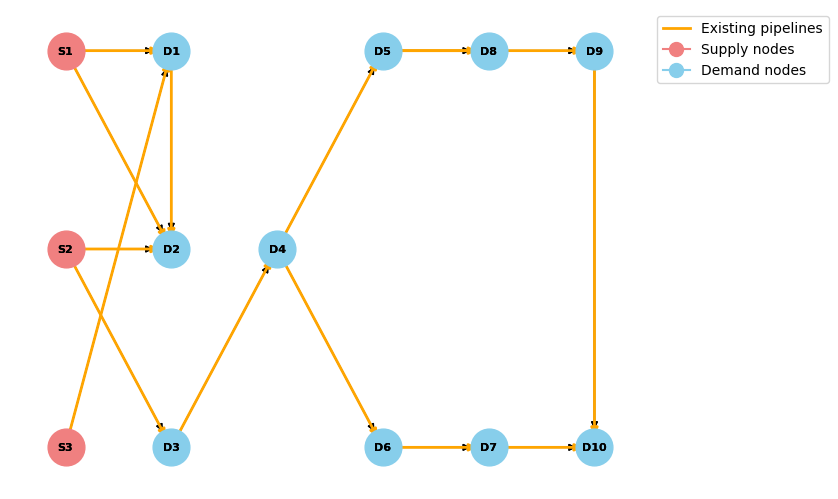

In [42]:
#plot original methane grid

# Add edges from the table with edge types from methane
edges_origin = [
    ('S1', 'D1', {'type': 'existing'}),
    ('S1', 'D2', {'type': 'existing'}),
    ('S2', 'D2', {'type': 'existing'}),
    ('S2', 'D3', {'type': 'existing'}),
    ('S3', 'D1', {'type': 'existing'}),
    ('D1', 'D2', {'type': 'existing'}),
    ('D3', 'D4', {'type': 'existing'}),
    ('D4', 'D5', {'type': 'existing'}),
    ('D4', 'D6', {'type': 'existing'}),
    ('D6', 'D7', {'type': 'existing'}),
    ('D5', 'D8', {'type': 'existing'}),
    ('D5', 'D9', {'type': 'existing'}),
    ('D9', 'D10', {'type': 'existing'}),
    ('D7', 'D10', {'type': 'existing'}),
]

# Separate nodes with 'S' in their names and others
s_nodes = [node for node in G.nodes if 'S' in node]
other_nodes = [node for node in G.nodes if 'S' not in node]

#plot methane grid
G.add_edges_from(edges_origin)

# Separate edges by type
new_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'new']
existing_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'existing']

# Plot the graph with node coordinates and different colors for edge types
pos = nodes
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=s_nodes, node_color='lightcoral', label='Supply nodes')
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G, pos, edgelist=new_edges, edge_color='green', label='New edges', width=2)
nx.draw_networkx_edges(G, pos, edgelist=existing_edges, edge_color='orange', label='Existing edges', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Existing pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

#output_filepath = os.path.join(output_folder, 'network_methane_plot.png')
plt.savefig(images_folder_path + 'network_origin_plot.png', bbox_inches='tight')


# Display the plot
plt.show()

In [ ]:
#plot methane grid
G.add_edges_from(edges_methane)

# Separate edges by type
new_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'new']
existing_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'existing']

# Plot the graph with node coordinates and different colors for edge types
pos = nodes
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=s_nodes, node_color='lightcoral', label='Supply nodes')
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G, pos, edgelist=new_edges, edge_color='green', label='New edges', width=2)
nx.draw_networkx_edges(G, pos, edgelist=existing_edges, edge_color='orange', label='Existing edges', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='New pipelines'),
    Line2D([0], [0], color='orange', lw=2, label='Existing pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

#output_filepath = os.path.join(output_folder, 'network_methane_plot.png')
plt.savefig(images_folder_path + 'network_methane_plot.png', bbox_inches='tight')


# Display the plot
plt.show()

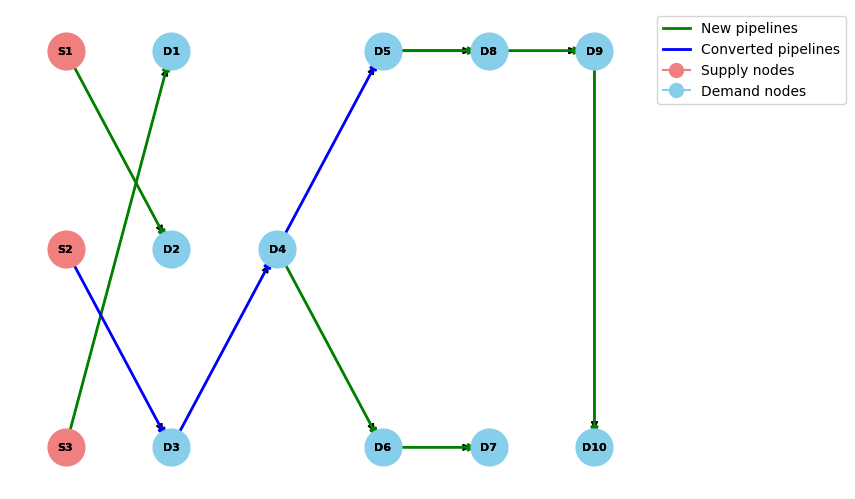

In [43]:
#plot hydrogen grid

G_hydrogen = nx.DiGraph()

G_hydrogen.add_edges_from(edges_hy)

# Separate edges by type
new_edges = [(u, v) for u, v, d in G_hydrogen.edges(data=True) if d['type'] == 'new']
converted_edges = [(u, v) for u, v, d in G_hydrogen.edges(data=True) if d['type'] == 'converted']

# Plot the graph with node coordinates and different colors for edge types
pos = nodes
nx.draw(G_hydrogen, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=s_nodes, node_color='lightcoral', label='Supply nodes')
nx.draw(G_hydrogen, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G_hydrogen, pos, edgelist=new_edges, edge_color='green', label='New edges', width=2)
nx.draw_networkx_edges(G_hydrogen, pos, edgelist=converted_edges, edge_color='blue', label='Existing edges', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='New pipelines'),
    Line2D([0], [0], color='blue', lw=2, label='Converted pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.savefig(images_folder_path + 'network_hydrogen_plot.png', bbox_inches='tight')

# Display the plot
plt.show()